# Modulprojekt DLT – BERT-Finetuning: Sentiment-Klassifikation

**Kurs:** Deep Learning Techniken für die CL
**Aufgabe:** Feintunen eines BERT-Modells für eine klassische NLP-Aufgabe.

Dieses Notebook ist eine **Vorlage**. Es implementiert die komplette Pipeline auf dem
Datensatz `rotten_tomatoes` (binäre Sentiment-Klassifikation). Ihre Aufgabe ist es,
die Pipeline zu verstehen, sauber auszuwerten und **eine eigene Untersuchung** hinzuzufügen
(siehe Abschnitt 8).

**Laufzeit:** Läuft auf der kostenlosen Colab-Stufe (T4-GPU) in wenigen Minuten,
auf CPU in ca. 10–30 Minuten. Setzen Sie in Colab: *Laufzeit → Laufzeittyp ändern → T4 GPU*.

**Wichtig für Reproduzierbarkeit:** Alle Zufallszahlen sind mit einem festen Seed
initialisiert. Das Test-Set wird **nur einmal ganz am Ende** benutzt.


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.listdir('/content/drive/MyDrive/Colab Notebooks')

Mounted at /content/drive


['DLT_MP']

## 0 – Einrichtung

Wir installieren die benötigten Pakete. In Colab müssen `transformers`, `datasets`
und `evaluate` in der Regel installiert werden; `peft` nur für die optionale LoRA-Aufgabe.


In [3]:
# In Colab ausführen. Lokal ggf. in einer venv installieren.
%pip install -q "transformers>=4.40" "datasets>=2.19" evaluate scikit-learn peft accelerate
# In Colab ist ein zu altes torchao vorinstalliert, das mit aktuellem peft
# kollidiert (ImportError in Abschnitt 7). LoRA auf BERT braucht torchao nicht,
# daher entfernen wir es. Danach: Laufzeit NICHT neu starten, einfach weiter.
%pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [4]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1 – Datensatz laden und inspizieren

**Bevor** man modelliert, schaut man sich die Daten an: Wie viele Beispiele gibt es?
Sind die Klassen balanciert? Wie lang sind die Texte? Das bestimmt spätere
Design-Entscheidungen (z. B. `max_length`).


In [5]:
from datasets import load_dataset

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")   # Splits: train / validation / test
print(ds)
labels = ds["train"].features["label"].names   # ['neg', 'pos']
print("Labels:", labels)
ds["train"][:2] # lets look at the first two examples

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})
Labels: ['neg', 'pos']


{'text': ['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .',
  'the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson\'s expanded vision of j . r . r . tolkien\'s middle-earth .'],
 'label': [1, 1]}

In [6]:
import collections
# Klassenverteilung pro Split
for split in ds:
    c = collections.Counter(ds[split]["label"])
    print(f"{split:11s}: n={len(ds[split]):5d}  neg={c[0]:5d}  pos={c[1]:5d}")

train      : n= 8530  neg= 4265  pos= 4265
validation : n= 1066  neg=  533  pos=  533
test       : n= 1066  neg=  533  pos=  533


50:50 Split --> balanciertes Datenset

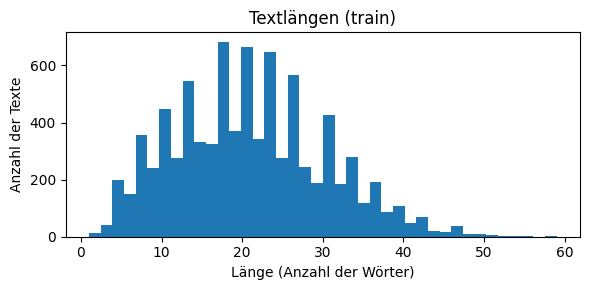

Median: 20  95. Perzentil: 37


In [7]:
import matplotlib.pyplot as plt
# Längenverteilung (in Wörtern) – hilft beim Wählen von max_length
lengths = [len(t.split()) for t in ds["train"]["text"]]
plt.figure(figsize=(6,3))
plt.hist(lengths, bins=40)
plt.xlabel("Länge (Anzahl der Wörter)"); plt.ylabel("Anzahl der Texte"); plt.title("Textlängen (train)")
plt.tight_layout(); plt.show()
print("Median:", int(np.median(lengths)), " 95. Perzentil:", int(np.percentile(lengths,95)))

*   50% der Reviews bestehen aus 20 oder weniger Wörtern und 50% aus 20 oder mehr.
*   Nur 5% der Reviews im Trainingset hat mehr als 37 Wörter.
* Wie kommt man von der Anzahl der Wörter zu der abgeleiteten max_lengths der Tokens? Ein Wort könnte ja auch in mehrere Subwort-Tokens zerlegt werden. Deswegen berechne ich die Verteilung nochmal mit dem Tokenizer ohne Truncation:



In [8]:
from transformers import AutoTokenizer


MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def get_token_length(batch):
    tokens = tokenizer(batch["text"], truncation=False)
    return {"token_length": [len(ids) for ids in tokens["input_ids"]]}

ds_lengths = ds["train"].map(get_token_length, batched=True)

lengths = ds_lengths["token_length"]

print("Median:", np.percentile(lengths, 50))
print("95%:", np.percentile(lengths, 95))
print("Maximum:", np.max(lengths))

text = ds["train"][0]["text"]
encoded = tokenizer(text)
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Median: 27.0
95%: 47.0
Maximum: 78
['[CLS]', 'the', 'rock', 'is', 'destined', 'to', 'be', 'the', '21st', 'century', "'", 's', 'new', '"', 'conan', '"', 'and', 'that', 'he', "'", 's', 'going', 'to', 'make', 'a', 'splash', 'even', 'greater', 'than', 'arnold', 'schwarz', '##ene', '##gger', ',', 'jean', '-', 'cl', '##aud', 'van', 'dam', '##me', 'or', 'steven', 'sega', '##l', '.', '[SEP]']


Da die maximale Tokenanzahl beim Trainingset bei 78 Tokens liegt, könnte man max_length auch verringern. Bringt aber nicht viel, weil wir nachher ohnehin dynamisches Padding verwenden.

## 2 – Baselines

Ein Modell ist nur so gut wie der Vergleich, gegen den es antritt. Wir berechnen zwei
Baselines:

1. **Majority-Class** – rät immer die häufigste Klasse. Untergrenze für "sinnvoll".
2. **TF-IDF + logistische Regression** – ein starker, klassischer Vektorraum-Baseline
   (Anknüpfung an das Kapitel zu Vektorraum-Repräsentationen).

Ihr feingetuntes BERT sollte **beide** schlagen.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

Xtr, ytr = ds["train"]["text"], ds["train"]["label"]
Xva, yva = ds["validation"]["text"], ds["validation"]["label"]

# 1) Majority class
maj = collections.Counter(ytr).most_common(1)[0][0]
pred_maj = [maj]*len(yva)
print(f"Majority : acc={accuracy_score(yva,pred_maj):.3f}  macro-F1={f1_score(yva,pred_maj,average='macro'):.3f}")

# 2) TF-IDF + LogReg
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2) # unigrams + bigrams, ngram appears in at least two docs
clf = LogisticRegression(max_iter=1000)
# learn vocabulary from training data, transform to TF-IDF feature vectors,
# train LogReg classifier to map vectors to their labels
clf.fit(vec.fit_transform(Xtr), ytr)
pred_lr = clf.predict(vec.transform(Xva)) # no fitting on validation data, avoid data leakage
print(f"TF-IDF+LR: acc={accuracy_score(yva,pred_lr):.3f}  macro-F1={f1_score(yva,pred_lr,average='macro'):.3f}")

Majority : acc=0.500  macro-F1=0.333
TF-IDF+LR: acc=0.749  macro-F1=0.749


## 3 – Tokenisierung

Wir laden den Tokenizer zum gewählten Modell und wandeln die Texte in Token-IDs um.
`distilbert-base-uncased` ist klein und schnell – ideal ohne starke GPU. Sie können
später `bert-base-uncased` ausprobieren und vergleichen (Abschnitt 8).


In [10]:
MAX_LENGTH = 128   # aus der Längenverteilung oben abgeleitet

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

ds_tok = ds.map(tokenize, batched=True)
ds_tok = ds_tok.remove_columns(["text"]).rename_column("label", "labels")
# Hinweis: KEIN set_format("torch") -- in Colab loest der Torch-Formatter von
# datasets teils einen ImportError (torchvision VideoReader) aus. Der
# DataCollatorWithPadding wandelt die Batches ohnehin selbst in Tensoren um.
ds_tok["train"][0].keys()

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])

## 4 – Feintuning mit dem `Trainer`

Wir laden `AutoModelForSequenceClassification` mit einem frischen Klassifikationskopf
(2 Labels) und trainieren mit der `Trainer`-API aus Kapitel 3 des HF-Kurses.

`compute_metrics` berechnet **Accuracy und Macro-F1**. Bei balancierten Daten sind beide
ähnlich; bei unbalancierten Aufgaben ist Macro-F1 aussagekräftiger.


In [11]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:"neg",1:"pos"}, label2id={"neg":0,"pos":1})

collator = DataCollatorWithPadding(tokenizer)  # dynamisches Padding pro Batch

def compute_metrics(eval_pred):
    logits, y = eval_pred
    pred = logits.argmax(-1)
    return {"accuracy": accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, average="macro")}

args = TrainingArguments(
    output_dir="out",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.426019,0.383973,0.832083,0.830437
2,0.252825,0.402792,0.855535,0.855484
3,0.159848,0.492595,0.845216,0.845185


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1602, training_loss=0.27014087707957674, metrics={'train_runtime': 168.3045, 'train_samples_per_second': 152.046, 'train_steps_per_second': 9.518, 'total_flos': 323059008078528.0, 'train_loss': 0.27014087707957674, 'epoch': 3.0})

* Ab Epoche 3: Tendenz zum Overfitting
* Epoche 2 bestes Modell (F1_Score)

## 5 – Evaluation auf dem Test-Set

Jetzt – und erst jetzt – benutzen wir das Test-Set. Wir berichten Accuracy und
Macro-F1, den vollständigen `classification_report` und eine Confusion-Matrix.


BERT test: acc=0.844  macro-F1=0.844

              precision    recall  f1-score   support

         neg       0.85      0.83      0.84       533
         pos       0.84      0.85      0.85       533

    accuracy                           0.84      1066
   macro avg       0.84      0.84      0.84      1066
weighted avg       0.84      0.84      0.84      1066



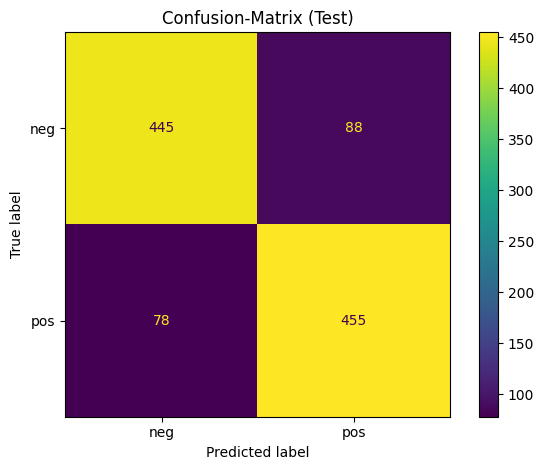

In [12]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pred_out = trainer.predict(ds_tok["test"])
y_true = pred_out.label_ids
y_pred = pred_out.predictions.argmax(-1)

print(f"BERT test: acc={accuracy_score(y_true,y_pred):.3f}  "
      f"macro-F1={f1_score(y_true,y_pred,average='macro'):.3f}\n")
print(classification_report(y_true, y_pred, target_names=labels))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)
plt.title("Confusion-Matrix (Test)"); plt.tight_layout(); plt.show()

## 6 – Qualitative Fehleranalyse

Zahlen allein sagen wenig. Schauen Sie sich falsch klassifizierte Beispiele an und
bilden Sie **Hypothesen**: Was verwirrt das Modell? Negationen? Ironie? Lange Sätze?
Diese Beobachtungen gehören in Ihren Bericht.


In [13]:
test_texts = ds["test"]["text"]
errors = [(test_texts[i], labels[y_true[i]], labels[y_pred[i]])
          for i in range(len(y_true)) if y_true[i] != y_pred[i]]
print(f"{len(errors)} Fehler von {len(y_true)} Beispielen\n")
for txt, gold, pred in errors[:10]:
    print(f"[gold={gold} | pred={pred}] {txt[:120]}")

166 Fehler von 1066 Beispielen

[gold=pos | pred=neg] it's like a " big chill " reunion of the baader-meinhof gang , only these guys are more harmless pranksters than politic
[gold=pos | pred=neg] red dragon " never cuts corners .
[gold=pos | pred=neg] mostly , [goldbacher] just lets her complicated characters be unruly , confusing and , through it all , human .
[gold=pos | pred=neg] at its worst , the movie is pretty diverting ; the pity is that it rarely achieves its best .
[gold=pos | pred=neg] grown-up quibbles are beside the point here . the little girls understand , and mccracken knows that's all that matters 
[gold=pos | pred=neg] devotees of star trek ii : the wrath of khan will feel a nagging sense of deja vu , and the grandeur of the best next ge
[gold=pos | pred=neg] reminiscent of alfred hitchcock's thrillers , most of the scary parts in 'signs' occur while waiting for things to happe
[gold=pos | pred=neg] works because we're never sure if ohlinger's on the level or merely 

*   z.B positive Rezession trotz negativ konnotierter Wörter




## 7 – (Optional) LoRA / Parameter-effizientes Feintuning

Statt alle Gewichte zu aktualisieren, trainiert **LoRA** nur kleine Adapter-Matrizen.
Bei BERT-base ist volles Feintuning schon billig – LoRA ist hier vor allem eine
**Untersuchung**: Wie viele Parameter werden trainiert, und wie ändert sich die
Genauigkeit? Vergleichen Sie mit Abschnitt 4.


In [14]:
from peft import LoraConfig, get_peft_model, TaskType

base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["q_lin","v_lin"],   # DistilBERT-Attention; bei BERT: ["query","value"]
)
lora_model = get_peft_model(base, lora_cfg)
lora_model.print_trainable_parameters()   # vergleiche mit ~67M des vollen Modells

# Danach: denselben Trainer-Block wie in Abschnitt 4, aber model=lora_model.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [15]:
args_lora = TrainingArguments(
    output_dir="out_lora",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer_lora = Trainer(
    model=lora_model, args=args_lora,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
trainer_lora.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.565970,0.430110,0.808630,0.808516
2,0.434666,0.411947,0.816135,0.815969
3,0.424946,0.407349,0.819887,0.819796


TrainOutput(global_step=1602, training_loss=0.47076444352015423, metrics={'train_runtime': 96.6514, 'train_samples_per_second': 264.766, 'train_steps_per_second': 16.575, 'total_flos': 328599939057024.0, 'train_loss': 0.47076444352015423, 'epoch': 3.0})

etwas schlechteres Ergebnis, allerdings deutlich schneller und keine Overfitting Tendenz erkennbar, profitiert eventuell von mehr Trainingsepochen  

## 8 – (Pflicht) Ihre eigene Untersuchung

Wählen Sie **mindestens eine** Erweiterung und werten Sie sie sauber aus:

- **Daten-Effizienz / Lernkurve:** Accuracy vs. Trainingsgröße (z. B. 250 / 1000 / 5000).
- **Volles Feintuning vs. LoRA vs. eingefrorener Encoder** (nur linearer Kopf).
- **Modellvergleich:** DistilBERT vs. BERT-base vs. `prajjwal1/bert-mini`
  (Accuracy / Größe / Trainingszeit).
- **Robustheit:** Wie fällt die Leistung auf gestörten Eingaben (Tippfehler, Groß-/Kleinschreibung)?
- **Hyperparameter-Sensitivität:** Lernrate / Epochen bei festem Rechenbudget.

Der Code unten ist ein Startpunkt für die **Lernkurve**.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '3.56', 'train_samples_per_second': '210.7', 'train_steps_per_second': '13.48', 'train_loss': '0.6549', 'epoch': '3'}
n=  250  acc=0.735  macro-F1=0.735


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '14.27', 'train_samples_per_second': '210.2', 'train_steps_per_second': '13.24', 'train_loss': '0.4168', 'epoch': '3'}
n= 1000  acc=0.800  macro-F1=0.800


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '72.21', 'train_samples_per_second': '207.7', 'train_steps_per_second': '13', 'train_loss': '0.2818', 'epoch': '3'}
n= 5000  acc=0.837  macro-F1=0.837


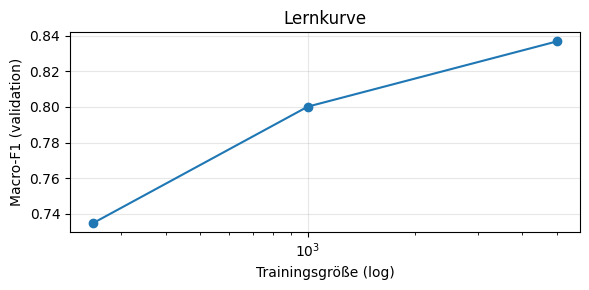

In [16]:
# Vollständiges Beispiel: Lernkurve (Macro-F1 vs. Trainingsgröße).
# Wir kapseln Training + Evaluation in eine Funktion und rufen sie in einer Schleife.
# Für Robustheit sollte man je Größe mehrere Seeds mitteln; hier ein Seed pro Größe,
# damit es auf CPU schnell bleibt.

def train_eval(n_train, seed=SEED, epochs=3):
    """Trainiert DistilBERT auf n_train Beispielen und gibt (acc, macro_f1) auf
    dem validation-Split zurück. Nutzt dieselbe Tokenisierung wie oben."""
    torch.manual_seed(seed)
    sub = ds_tok["train"].shuffle(seed=seed).select(range(n_train))

    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0: "neg", 1: "pos"}, label2id={"neg": 0, "pos": 1})

    a = TrainingArguments(
        output_dir=f"out_lc_{n_train}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy="no",       # wir evaluieren einmal am Ende selbst
        save_strategy="no",
        seed=seed,
        report_to="none",
        logging_strategy="no",
        disable_tqdm=True,
    )
    tr = Trainer(model=m, args=a, train_dataset=sub,
                 data_collator=collator, compute_metrics=compute_metrics)
    tr.train()

    out = tr.predict(ds_tok["validation"])
    yp = out.predictions.argmax(-1)
    yt = out.label_ids
    return accuracy_score(yt, yp), f1_score(yt, yp, average="macro")


sizes = [250, 1000, 5000]
lc = {}
for n in sizes:
    acc, mf1 = train_eval(n)
    lc[n] = {"accuracy": acc, "macro_f1": mf1}
    print(f"n={n:5d}  acc={acc:.3f}  macro-F1={mf1:.3f}")

# Plot der Lernkurve
plt.figure(figsize=(6, 3))
plt.plot(sizes, [lc[n]["macro_f1"] for n in sizes], marker="o")
plt.xscale("log")
plt.xlabel("Trainingsgröße (log)"); plt.ylabel("Macro-F1 (validation)")
plt.title("Lernkurve"); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

# Ergebnisse für den Bericht sichern
import json, os
os.makedirs("results", exist_ok=True)
with open("results/learning_curve.json", "w") as f:
    json.dump(lc, f, indent=2)


## 9 – Speichern der Ergebnisse

Speichern Sie Modell und Metriken reproduzierbar. Committen Sie die `metrics.json`
(nicht das große Modell) ins Repository.


In [18]:
import json, os
os.makedirs("/content/drive/MyDrive/Colab Notebooks/DLT_MP/results", exist_ok=True)
metrics = {
    "model": MODEL_NAME, "seed": SEED, "max_length": MAX_LENGTH,
    "test_accuracy": float(accuracy_score(y_true, y_pred)),
    "test_macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "baseline_majority_f1": float(f1_score(yva, pred_maj, average="macro")),
    "baseline_tfidf_f1": float(f1_score(yva, pred_lr, average="macro")),
}
with open("/content/drive/MyDrive/Colab Notebooks/DLT_MP/results/metrics_starter.json","w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))
# trainer.save_model("results/model")   # optional, groß

{
  "model": "distilbert-base-uncased",
  "seed": 42,
  "max_length": 128,
  "test_accuracy": 0.8442776735459663,
  "test_macro_f1": 0.8442639686831137,
  "baseline_majority_f1": 0.3333333333333333,
  "baseline_tfidf_f1": 0.7485495000704127
}
